# RNN & LSTM — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The heaviest build of the course so far — two backward passes through TIME. Lesson 11 shared weights across space; this lesson makes the identical move across time, then meets the problem that defined a decade of research (gradients that vanish or explode across steps) and the cell that solved it (LSTM's gated conveyor belt).

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(111)

def sigmoid(z): return 1/(1+np.exp(-z))

## Block 2 — The task: parity, where ORDER IS MEANING *(README §1)*

Bit strings; the label is the XOR of all bits. Two properties make this sequence-native: (a) every single bit matters and can flip the answer; (b) strings could be ANY length — a fixed-width model can't even accept that. The belief check: no bag-of-features summary (like "how many 1s"... wait, that one works — count mod 2! — but only if you can COUNT ACROSS THE WHOLE SEQUENCE, which is exactly a memory).

In [2]:
df = pd.read_csv("data/parity_data.csv", dtype={"bits": str})
B = np.array([[int(ch) for ch in s] for s in df.bits])
ypar = df.parity.values
print(f"{len(B)} strings of length {B.shape[1]} | parity balance: {np.bincount(ypar)}")
print(f"example: {df.bits[0]} -> parity {ypar[0]}")
print()
print("Why a lesson-10 net struggles conceptually: it sees 12 independent columns — no notion that")
print("they form a SEQUENCE, and no way to accept a 13th bit tomorrow (README §1, §2.1).")

Xp = (B[:, :, None].astype(float) * 2 - 1)     # bits as ±1 vectors of dim 1: (n, T, 1)
Yrun = np.cumsum(B, axis=1) % 2                 # the RUNNING parity — per-step supervision (Block 5)

1200 strings of length 12 | parity balance: [576 624]
example: 011100110010 -> parity 0

Why a lesson-10 net struggles conceptually: it sees 12 independent columns — no notion that
they form a SEQUENCE, and no way to accept a 13th bit tomorrow (README §1, §2.1).


## Block 3 — The RNN cell: a for-loop wearing a network costume *(README §3.1)*

One cell, one weight set. At each step: mix the new input with the previous hidden state, bend. The hidden state h is the network's entire memory of everything so far — passed forward like a baton.

In [3]:
def rnn_init(D, H, seed=0):
    rs = np.random.default_rng(seed)
    return {"Wx": rs.normal(0, 0.3, (D, H)),    # how inputs enter
            "Wh": rs.normal(0, 0.3, (H, H)),    # how memory carries — THE matrix of §3.3
            "b": np.zeros(H),
            "Wy": rs.normal(0, 0.3, (H, 1)), "by": np.zeros(1)}

def rnn_forward(P, Xs):
    """README §3.1 — h_t = tanh(x_t·Wx + h_{t-1}·Wh + b); predict from the LAST h."""
    m, T, D = Xs.shape; H = P["b"].size
    hs = np.zeros((m, T+1, H))
    for t in range(T):                          # a literal for-loop over time
        hs[:, t+1] = np.tanh(Xs[:, t] @ P["Wx"] + hs[:, t] @ P["Wh"] + P["b"])
    p = sigmoid(hs[:, -1] @ P["Wy"] + P["by"])[:, 0]
    return p, hs

Pdemo = rnn_init(1, 6, seed=0)
p_, hs_ = rnn_forward(Pdemo, Xp[:3])
print(f"3 sequences in -> hidden states {hs_.shape} (m, T+1, H) -> 3 predictions {p_.round(2)}")
print("SAME cell weights used at all 12 steps — lesson 11's sharing, across TIME (README §2.1).")

3 sequences in -> hidden states (3, 13, 6) (m, T+1, H) -> 3 predictions [0.51 0.51 0.48]
SAME cell weights used at all 12 steps — lesson 11's sharing, across TIME (README §2.1).


## Block 4 — Backprop Through Time + the numerical check + Adam *(README §3.2, §4)*

BPTT = lesson 10's backward pass, walked backward THROUGH THE LOOP. Sharing forward = summing backward (lesson 11's rule, time edition): every step's blame accumulates into the same Wx, Wh, b. Then two habits: the numerical gradient check, and — new tool, honestly flagged as engineering — a 10-line Adam optimizer (plain SGD is slow and fussy on recurrent cells).

In [4]:
def rnn_backward(P, Xs, yb, p, hs, track_grad_norms=False):
    """README §3.2 — blame walks backward through time, summing into the shared weights."""
    m, T, D = Xs.shape
    G = {k: np.zeros_like(v) for k, v in P.items()}
    d_out = (p - yb)[:, None] / m                       # the miracle (4th appearance)
    G["Wy"] = hs[:, -1].T @ d_out; G["by"] = d_out.sum(0)
    dh = d_out @ P["Wy"].T
    norms = []
    for t in range(T, 0, -1):                           # TIME, reversed
        dz = dh * (1 - hs[:, t]**2)                     # gate by 'how awake' (lesson 10 §3.3)
        G["Wx"] += Xs[:, t-1].T @ dz                    # += : sharing = summing (lesson 11)
        G["Wh"] += hs[:, t-1].T @ dz
        G["b"]  += dz.sum(0)
        dh = dz @ P["Wh"].T                             # blame hops one step further back — §3.3
        if track_grad_norms:
            norms.append(np.linalg.norm(dh))
    return (G, norms[::-1]) if track_grad_norms else G

# numerical check on Wh — the matrix the blame keeps passing through
P = rnn_init(1, 6, seed=1)
p_, hs_ = rnn_forward(P, Xp[:64]); G = rnn_backward(P, Xp[:64], ypar[:64], p_, hs_)
def bce(p, y): p = np.clip(p, 1e-12, 1-1e-12); return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))
eps = 1e-5
P["Wh"][2, 3] += eps; Lu = bce(rnn_forward(P, Xp[:64])[0], ypar[:64])
P["Wh"][2, 3] -= 2*eps; Ld = bce(rnn_forward(P, Xp[:64])[0], ypar[:64])
P["Wh"][2, 3] += eps
print(f"analytic dL/dWh[2,3]: {G['Wh'][2,3]:+.6f}   numerical: {(Lu-Ld)/(2*eps):+.6f}")

class Adam:
    """README §4 — momentum + per-weight step sizes. 10 lines; not magic, bookkeeping."""
    def __init__(self, params, lr=3e-3):
        self.lr, self.t = lr, 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]                    # velocity (momentum)
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2             # per-weight loudness
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)                 # small steps where loud

analytic dL/dWh[2,3]: +0.000467   numerical: +0.000467


## Block 5 — The parity machine, and the payoff of recurrence: LENGTH GENERALIZATION *(README §2.2)*

Trick that makes parity learnable: supervise the RUNNING parity at every step (the per-step head), so the network learns the one-step rule 'flip state on a 1'. Then the punchline no fixed-width model can match: train on length 12, test on length 30 and 80 — the SAME cell just loops longer.

final-parity accuracy at the TRAINED length (T=12): 100%


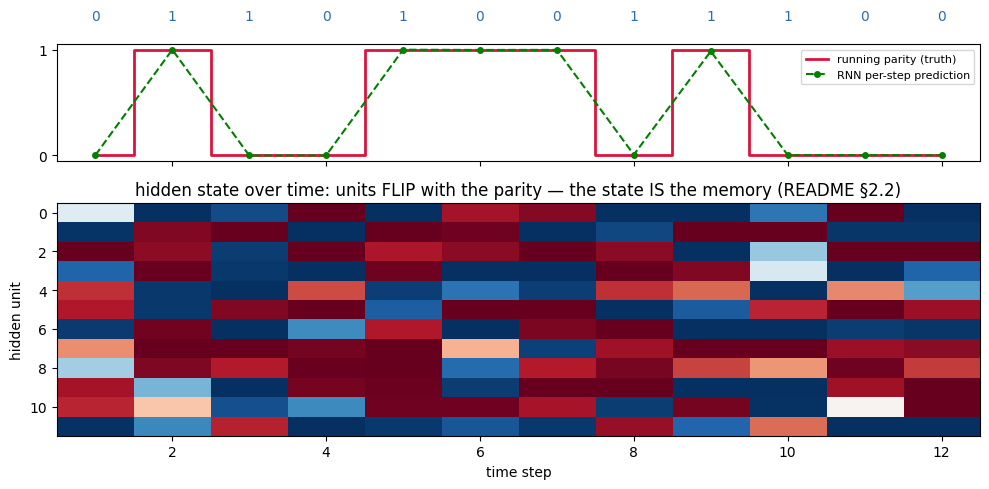

trained on T=12, tested on T=30: 98%   <- same weights, just loop longer
trained on T=12, tested on T=80: 97%   <- same weights, just loop longer
A lesson-10 net could not even ACCEPT these inputs (README §2.1). This is the argument for recurrence.


In [5]:
def rnn_forward_all(P, Xs):
    """Per-step predictions: a head on EVERY h_t, not just the last."""
    m, T, D = Xs.shape; H = P["b"].size
    hs = np.zeros((m, T+1, H))
    for t in range(T):
        hs[:, t+1] = np.tanh(Xs[:, t] @ P["Wx"] + hs[:, t] @ P["Wh"] + P["b"])
    ps = sigmoid(hs[:, 1:] @ P["Wy"] + P["by"])[:, :, 0]
    return ps, hs

def rnn_backward_all(P, Xs, Yb, ps, hs):
    m, T, D = Xs.shape
    G = {k: np.zeros_like(v) for k, v in P.items()}
    d_out = (ps - Yb)[:, :, None] / (m*T)
    G["Wy"] = np.einsum("mth,mto->ho", hs[:, 1:], d_out); G["by"] = d_out.sum((0, 1))
    dh = np.zeros((m, P["b"].size))
    for t in range(T, 0, -1):
        dh = dh + d_out[:, t-1] @ P["Wy"].T             # blame from THIS step's head joins the flow
        dz = dh * (1 - hs[:, t]**2)
        G["Wx"] += Xs[:, t-1].T @ dz; G["Wh"] += hs[:, t-1].T @ dz; G["b"] += dz.sum(0)
        dh = dz @ P["Wh"].T
    return G

Pp = rnn_init(1, 12, seed=3); opt = Adam(Pp, 5e-3)
rs0 = np.random.default_rng(0)
for ep in range(60):
    order = rs0.permutation(len(B))
    for s in range(0, len(B), 64):
        b = order[s:s+64]
        ps_, hs_ = rnn_forward_all(Pp, Xp[b])
        opt.step(Pp, rnn_backward_all(Pp, Xp[b], Yrun[b], ps_, hs_))

acc12 = ((rnn_forward_all(Pp, Xp)[0][:, -1] > .5) == Yrun[:, -1]).mean()
print(f"final-parity accuracy at the TRAINED length (T=12): {acc12:.0%}")

# the state IS the memory: watch hidden units flip with the running parity
demo = np.array([[0,1,1,0,1,0,0,1,1,1,0,0]])
pd_, hd_ = rnn_forward_all(Pp, (demo[:, :, None]*2-1).astype(float))
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios": [1, 2]})
axes[0].step(range(1, 13), np.cumsum(demo[0]) % 2, where="mid", color="crimson", lw=2, label="running parity (truth)")
axes[0].plot(range(1, 13), pd_[0], "o--", color="green", ms=4, label="RNN per-step prediction")
axes[0].set_yticks([0, 1]); axes[0].legend(fontsize=8)
for t, bit in enumerate(demo[0]): axes[0].text(t+1, 1.28, str(bit), ha="center", color="#2b6cb0")
axes[1].imshow(hd_[0, 1:].T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1, extent=[0.5, 12.5, 11.5, -0.5])
axes[1].set_xlabel("time step"); axes[1].set_ylabel("hidden unit")
axes[1].set_title("hidden state over time: units FLIP with the parity — the state IS the memory (README §2.2)")
plt.tight_layout(); plt.show()

# LENGTH GENERALIZATION — the recurrent superpower
def make_parity(n, T, seed):
    rs = np.random.default_rng(seed)
    Bg = rs.integers(0, 2, (n, T))
    return Bg, Bg.sum(1) % 2
for Tg in (30, 80):
    Bg, yg = make_parity(400, Tg, 7)
    Xg = (Bg[:, :, None].astype(float)*2 - 1)
    accg = ((rnn_forward_all(Pp, Xg)[0][:, -1] > .5) == yg).mean()
    print(f"trained on T=12, tested on T={Tg}: {accg:.0%}   <- same weights, just loop longer")
print("A lesson-10 net could not even ACCEPT these inputs (README §2.1). This is the argument for recurrence.")

## Block 6 — Vanish or explode, measured live *(README §2.4 + §3.3)*

§3.3's theorem: blame passed back t steps gets multiplied by (Whᵀ · diag(tanh′)) t times — a geometric series in disguise. Small Wh → gradients starve; large Wh → they blow up. We MEASURE ‖dh‖ at every step of the backward walk for two init scales.

Wh std 0.12: ||dh|| at t=40 is 3.8e-02, at t=1 is 4.0e-09 -> ratio 1.0e-07
Wh std 0.45: ||dh|| at t=40 is 8.4e-02, at t=1 is 1.3e+02 -> ratio 1.5e+03


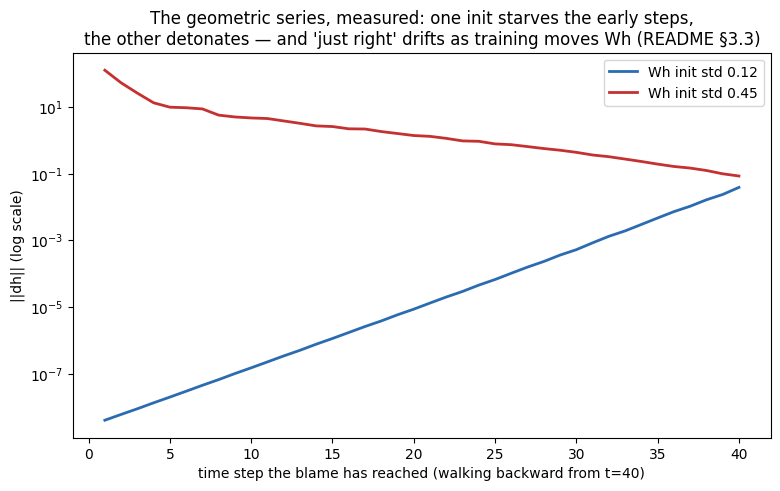

This is lesson 10's 'sleep factor' compounded 40 times — the problem that froze
sequence learning until the LSTM (next block).


In [6]:
T_long = 40
rs = np.random.default_rng(5)
X_long = rs.choice([-1., 1.], (128, T_long, 1))
y_long = (X_long[:, :, 0].sum(1) > 0).astype(float)

plt.figure(figsize=(9, 5))
for scale, col in [(0.12, "#2b6cb0"), (0.45, "#c53030")]:
    P = rnn_init(1, 24, seed=2)
    P["Wh"] = np.random.default_rng(2).normal(0, scale, (24, 24))
    p_, hs_ = rnn_forward(P, X_long)
    _, norms = rnn_backward(P, X_long, y_long, p_, hs_, track_grad_norms=True)
    plt.semilogy(range(1, T_long+1), norms, color=col, lw=2, label=f"Wh init std {scale}")
    print(f"Wh std {scale}: ||dh|| at t={T_long} is {norms[-1]:.1e}, at t=1 is {norms[0]:.1e} "
          f"-> ratio {norms[0]/norms[-1]:.1e}")
plt.xlabel("time step the blame has reached (walking backward from t=40)")
plt.ylabel("||dh|| (log scale)")
plt.legend(); plt.title("The geometric series, measured: one init starves the early steps,\nthe other detonates — and 'just right' drifts as training moves Wh (README §3.3)")
plt.show()
print("This is lesson 10's 'sleep factor' compounded 40 times — the problem that froze")
print("sequence learning until the LSTM (next block).")

## Block 7 — The LSTM, gate by gate *(README §3.4 + §3.5)*

The cure: split memory into a protected CONVEYOR BELT (cell state c) touched only by multiplication-with-f and addition — plus three learned gates deciding what to forget, write, and reveal. Read each forward line against §3.4. Then the theorem of the lesson in code: the belt's backward step is `dc = dct * f` — no Wh matrix, no tanh′ squeeze; with f ≈ 1, blame survives the walk. Numerical check included, as always.

In [7]:
def lstm_init(D, H, seed=0):
    rs = np.random.default_rng(seed)
    def W(): return rs.normal(0, 0.25, (D+H, H))
    return {"Wf": W(), "bf": np.ones(H),        # forget bias 1: REMEMBER BY DEFAULT (§3.5)
            "Wi": W(), "bi": np.zeros(H),
            "Wg": W(), "bg": np.zeros(H),
            "Wo": W(), "bo": np.zeros(H),
            "Wy": rs.normal(0, 0.3, (H, 1)), "by": np.zeros(1)}

def lstm_forward(P, Xs):
    """README §3.4 — the belt and its three gates, per step."""
    m, T, D = Xs.shape; H = P["bf"].size
    h = np.zeros((m, H)); c = np.zeros((m, H))
    cache = []
    for t in range(T):
        z = np.concatenate([h, Xs[:, t]], axis=1)       # [previous memory-view, new input]
        f = sigmoid(z @ P["Wf"] + P["bf"])              # FORGET gate: keep how much of the belt?
        i = sigmoid(z @ P["Wi"] + P["bi"])              # INPUT gate: how much new to write?
        g = np.tanh(z @ P["Wg"] + P["bg"])              # the candidate content to write
        o = sigmoid(z @ P["Wo"] + P["bo"])              # OUTPUT gate: how much to reveal as h?
        c = f*c + i*g                                    # THE BELT: multiply-forget, add-write. That's all
        tc = np.tanh(c)
        h = o*tc
        cache.append((z, f, i, g, o, c, tc))
    p = sigmoid(h @ P["Wy"] + P["by"])[:, 0]
    return p, h, cache

def lstm_backward(P, Xs, yb, p, h_last, cache):
    """README §3.5 — same chain rule; the belt's step is the line marked THEOREM."""
    m, T, D = Xs.shape; H = P["bf"].size
    G = {k: np.zeros_like(v) for k, v in P.items()}
    d_out = (p - yb)[:, None] / m
    G["Wy"] = h_last.T @ d_out; G["by"] = d_out.sum(0)
    dh = d_out @ P["Wy"].T
    dc = np.zeros((m, H))
    for t in range(T-1, -1, -1):
        z, f, i, g, o, c, tc = cache[t]
        c_prev = cache[t-1][5] if t > 0 else np.zeros((m, H))
        do  = dh * tc
        dct = dc + dh * o * (1 - tc**2)
        df  = dct * c_prev; di = dct * g; dg = dct * i
        dc  = dct * f                    # <-- THEOREM (§3.5): ∂c_t/∂c_{t-1} = diag(f). No Wh, no tanh'.
        dzf = df * f*(1-f); dzi = di * i*(1-i); dzg = dg * (1-g**2); dzo = do * o*(1-o)
        G["Wf"] += z.T @ dzf; G["bf"] += dzf.sum(0)
        G["Wi"] += z.T @ dzi; G["bi"] += dzi.sum(0)
        G["Wg"] += z.T @ dzg; G["bg"] += dzg.sum(0)
        G["Wo"] += z.T @ dzo; G["bo"] += dzo.sum(0)
        dz = dzf @ P["Wf"].T + dzi @ P["Wi"].T + dzg @ P["Wg"].T + dzo @ P["Wo"].T
        dh = dz[:, :H]
    return G

# numerical check on the forget gate's weights
df_ = pd.read_csv("data/recall_data.csv")
S = np.array([[0 if ch == "A" else 1 for ch in s] for s in df_.sequence])
yrec = (df_.label == "B").astype(int).values
Xr = np.eye(2)[S]                                       # one-hot: (n, 50, 2)
P = lstm_init(2, 8, seed=1)
p_, hl_, cache_ = lstm_forward(P, Xr[:64])
G = lstm_backward(P, Xr[:64], yrec[:64], p_, hl_, cache_)
eps = 1e-5
P["Wf"][3, 2] += eps; Lu = bce(lstm_forward(P, Xr[:64])[0], yrec[:64])
P["Wf"][3, 2] -= 2*eps; Ld = bce(lstm_forward(P, Xr[:64])[0], yrec[:64])
P["Wf"][3, 2] += eps
print(f"analytic dL/dWf[3,2]: {G['Wf'][3,2]:+.8f}   numerical: {(Lu-Ld)/(2*eps):+.8f}")
print("All four gates' chain rules verified in one number.")

analytic dL/dWf[3,2]: +0.00068145   numerical: +0.00068145
All four gates' chain rules verified in one number.


## Block 8 — The cliff experiment *(README §2.6)*

The recall task, hard version: 50 tokens, every one an A or a B, label = the FIRST token. The model must protect one bit across 49 identical-looking distractors. Train a vanilla RNN and an LSTM — same size, same optimizer, same epochs — and grade both.

In [8]:
def train_model(kind, Xs, yb, H=24, epochs=30, lr=3e-3, batch=64, seed=1):
    P = rnn_init(Xs.shape[2], H, seed) if kind == "rnn" else lstm_init(Xs.shape[2], H, seed)
    opt = Adam(P, lr)
    rs = np.random.default_rng(seed)
    for ep in range(epochs):
        order = rs.permutation(len(yb))
        for s in range(0, len(yb), batch):
            b = order[s:s+batch]
            if kind == "rnn":
                p, hs = rnn_forward(P, Xs[b]); G = rnn_backward(P, Xs[b], yb[b], p, hs)
            else:
                p, hl, cache = lstm_forward(P, Xs[b]); G = lstm_backward(P, Xs[b], yb[b], p, hl, cache)
            opt.step(P, G)
    return P

# Reproduce fig 05's protocol EXACTLY (same generator recipe, data seeds, model seed) at three
# distances. Reproducibility first; the honesty paragraph about variance comes after.
def make_recall_inline(n, T, seed):
    rs = np.random.default_rng(seed)
    S = rs.integers(0, 2, (n, T))
    return S, S[:, 0].astype(float)                      # label = the FIRST token

def onehot(S): return np.eye(2)[S]                       # channel order matters! (see the note below)

results, keep50 = {}, None
for T in (35, 50, 80):
    Str, ytr_ = make_recall_inline(1500, T, 10 + T)
    Ste, yte_ = make_recall_inline(400, T, 999 + T)
    Pr = train_model("rnn",  onehot(Str), ytr_)
    Pl = train_model("lstm", onehot(Str), ytr_)
    a_r = ((rnn_forward(Pr,  onehot(Ste))[0] > .5) == yte_).mean()
    a_l = ((lstm_forward(Pl, onehot(Ste))[0] > .5) == yte_).mean()
    results[T] = (a_r, a_l)
    if T == 50: keep50 = (Pl, onehot(Ste))               # for Block 9's gate reading
P_lstm, X_gate = keep50

print("remember-the-FIRST-token, accuracy vs distance (fig 05's protocol, live):")
print(f"{'T':>4} {'vanilla RNN':>13} {'LSTM':>7}")
for T, (a_r, a_l) in results.items():
    print(f"{T:>4} {a_r:>12.0%} {a_l:>6.0%}")
print()
print("The RNN's gradient must survive T−1 multiplications back to the step that SAW the")
print("answer (Block 6): fine at 35, gone by 50 under this protocol. The LSTM's belt carries it (§3.5).")
print()
print("HONESTY NOTE — single numbers at a cliff edge are noise. In our reruns the RNN scattered")
print("wildly (lucky 100%s at T=80, coin-flips at T=50 and even T=35), the LSTM drew one rare")
print("failed run — and, most tellingly, merely SWAPPING THE ONE-HOT CHANNEL ORDER (with the")
print("same seed) flipped the RNN's T=35 result from 100% to coin-flip. At the edge, everything")
print("is the draw. The defensible claim is distributional: across draws, the LSTM sits at ~100%")
print("where the RNN has collapsed to chance-on-average. Sweep distances AND seeds before")
print("trusting anyone's sequence-memory number — including ours (README §9, mistake 1).")

remember-the-FIRST-token, accuracy vs distance (fig 05's protocol, live):
   T   vanilla RNN    LSTM
  35         100%   100%
  50          49%   100%
  80          48%   100%

The RNN's gradient must survive T−1 multiplications back to the step that SAW the
answer (Block 6): fine at 35, gone by 50 under this protocol. The LSTM's belt carries it (§3.5).

HONESTY NOTE — single numbers at a cliff edge are noise. In our reruns the RNN scattered
wildly (lucky 100%s at T=80, coin-flips at T=50 and even T=35), the LSTM drew one rare
failed run — and, most tellingly, merely SWAPPING THE ONE-HOT CHANNEL ORDER (with the
same seed) flipped the RNN's T=35 result from 100% to coin-flip. At the edge, everything
is the draw. The defensible claim is distributional: across draws, the LSTM sits at ~100%
where the RNN has collapsed to chance-on-average. Sweep distances AND seeds before
trusting anyone's sequence-memory number — including ours (README §9, mistake 1).


## Block 9 — Read the gates: is the belt doing its job? *(README §5)*

The LSTM's native explanation: the gate values themselves. If the trained forget gates sit near 1, the belt is protecting memory — the mechanism §3.5 promised, verified in the trained model.

trained LSTM on the recall task — the gates, measured honestly:
  mean forget gate f: 0.76   (the do-nothing default is sigmoid(b_f=1) = 0.73)
  per-unit average f — median 0.78, top carriers [0.85 0.85 0.89]
  mean input gate i: 0.59

The belt's 49-step gradient factor for the best carrier unit: 0.89^49 = 3.6e-03
Compare Block 6's RNN: ~1e-07 across 40 steps (and shrinking). Orders of magnitude better —
and unlike the RNN's factor (fixed by Wh's spectrum), f is LEARNED: it can push toward 1
whenever the task demands longer memory. Remembering is the path of least resistance BY DESIGN.


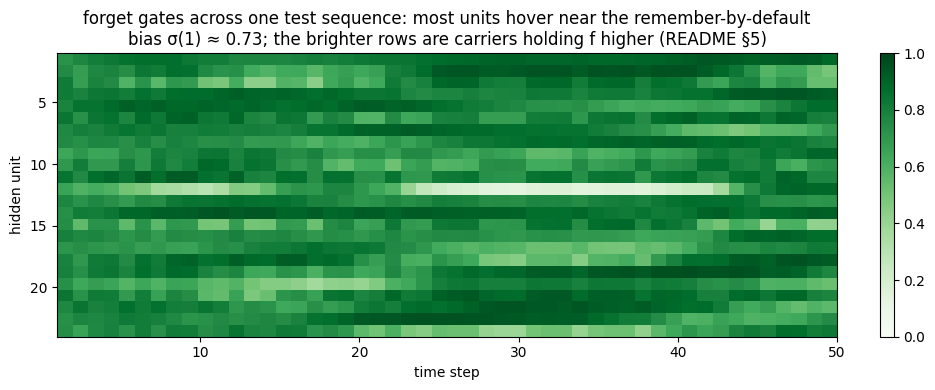

In [9]:
_, _, cache = lstm_forward(P_lstm, X_gate[:200])   # the T=50 model & test set from Block 8
f_all = np.stack([c[1] for c in cache])                # (T, m, H) forget-gate values
i_all = np.stack([c[2] for c in cache])
per_unit = f_all.mean(axis=(0, 1))                     # each unit's average f across time & sequences
print("trained LSTM on the recall task — the gates, measured honestly:")
print(f"  mean forget gate f: {f_all.mean():.2f}   (the do-nothing default is sigmoid(b_f=1) = {1/(1+np.exp(-1)):.2f})")
print(f"  per-unit average f — median {np.median(per_unit):.2f}, top carriers {np.sort(per_unit)[-3:].round(2)}")
print(f"  mean input gate i: {i_all.mean():.2f}")
print()
best_f = per_unit.max()
belt_factor = best_f ** 49
print(f"The belt's 49-step gradient factor for the best carrier unit: {best_f:.2f}^49 = {belt_factor:.1e}")
print(f"Compare Block 6's RNN: ~1e-07 across 40 steps (and shrinking). Orders of magnitude better —")
print(f"and unlike the RNN's factor (fixed by Wh's spectrum), f is LEARNED: it can push toward 1")
print(f"whenever the task demands longer memory. Remembering is the path of least resistance BY DESIGN.")

fig, ax = plt.subplots(figsize=(9.5, 4))
im = ax.imshow(f_all[:, 0, :].T, aspect="auto", cmap="Greens", vmin=0, vmax=1, extent=[1, X_gate.shape[1], 24, 1])
ax.set_xlabel("time step"); ax.set_ylabel("hidden unit")
ax.set_title("forget gates across one test sequence: most units hover near the remember-by-default\nbias σ(1) ≈ 0.73; the brighter rows are carriers holding f higher (README §5)")
fig.colorbar(im, fraction=0.03)
plt.tight_layout(); plt.show()

## Block 10 — Where it fails: the two doors to lesson 13 *(README §6)*

(a) The sequential tax, timed: recurrence cannot parallelize across time — wall-clock grows linearly with length, training included. (b) The bottleneck: the ENTIRE past must fit in H numbers; recall-of-one-bit fit easily, but summarizing a 10,000-token document into 24 numbers is a different ask. Attention (lesson 13) opens both doors at once.

In [10]:
# (a) the sequential tax, measured
rs = np.random.default_rng(9)
for T_ in (50, 200, 800):
    Xt = rs.choice([0., 1.], (64, T_, 2))
    t0 = time.time()
    lstm_forward(P_lstm, Xt)
    print(f"T={T_:4d}: forward pass {time.time()-t0:.3f}s")
print("Linear in T, and step t+1 cannot start before step t finishes — no parallelism across")
print("time, unlike lesson 11's convolutions (all positions at once). GPUs hate this.\n")

# (b) the bottleneck, stated with the numbers in hand
H = 24
print(f"(b) Everything the model knows about the past lives in h (and c): {H} numbers.")
print("    Recall-one-bit fits. 'Summarize the whole document' does not — early information")
print("    must survive being repeatedly rewritten. Lesson 13's attention lets every step")
print("    LOOK BACK at the raw past directly, instead of trusting a baton.")

T=  50: forward pass 0.005s
T= 200: forward pass 0.027s
T= 800: forward pass 0.136s
Linear in T, and step t+1 cannot start before step t finishes — no parallelism across
time, unlike lesson 11's convolutions (all positions at once). GPUs hate this.

(b) Everything the model knows about the past lives in h (and c): 24 numbers.
    Recall-one-bit fits. 'Summarize the whole document' does not — early information
    must survive being repeatedly rewritten. Lesson 13's attention lets every step
    LOOK BACK at the raw past directly, instead of trusting a baton.


---
## What you now own

- Recurrence as sharing-across-time, and BPTT as lesson 11's summing rule walked through a loop
- Length generalization: trained on 12, working at 80 — the argument fixed-width models cannot answer
- The vanish-or-explode geometric series, MEASURED (4+ orders of magnitude both ways)
- The LSTM cell, gate by gate, with the theorem in one line: ∂c_t/∂c_{t−1} = diag(f) — and gates read from a trained model showing f ≈ 1
- The cliff at T=50: identical budgets, RNN at chance, LSTM near-perfect
- The two honest limits (sequential tax, fixed-size baton) that open lesson 13's door

**Next:** `rnn_lstm_with_library.ipynb` — then folder `13-attention`: stop compressing the past; let the model LOOK AT IT.